# Visualization & Figures for Master Thesis
## Publication-ready plots for model comparison and validation

In [10]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
from pathlib import Path

# Style for thesis
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['legend.fontsize'] = 10

## 1. Load Data

In [11]:
# Load model datasets
fsm_ds = xr.open_dataset("../data/processed/fsm2_sd_all.nc")
senorge_ds = xr.open_dataset("../data/processed/senorge_all.nc")
snowpack_ds = xr.open_dataset("../data/processed/snowpack_all.nc")

# Load validation results
validation_results = pd.read_csv('../data/processed/multi_station_validation_results.csv')

# Extract snow depth and convert to meters
fsm_sd = fsm_ds["snow_depth"] / 1000.0  # FSM2: mm to m
senorge_sd = senorge_ds["snow_depth"] / 100.0  # seNorge: cm to m
snowpack_sd = snowpack_ds["HS_mod"] / 100.0  # SNOWPACK: HS_mod in cm to m

print(f"FSM2 snow depth shape: {fsm_sd.shape}")
print(f"seNorge snow depth shape: {senorge_sd.shape}")
print(f"SNOWPACK snow depth shape: {snowpack_sd.shape}")
print(f"\nValidation results loaded: {validation_results.shape[0]} stations")

FSM2 snow depth shape: (1461, 1550, 1195)
seNorge snow depth shape: (1461, 1550, 1195)
SNOWPACK snow depth shape: (4484, 6575)

Validation results loaded: 11 stations


In [12]:
# Check if SNOWPACK validation results are available
if 'SNOWPACK_Bias' not in validation_results.columns:
    print("⚠️  WARNING: SNOWPACK columns missing from validation results")
    print("Some figures will show only FSM2 and seNorge")
    print("\nTo fix: Run notebook 10 (multi_station_validation) first to generate all metrics")
else:
    print("✓ All validation columns available (FSM2, seNorge, SNOWPACK)")

⚠️  WARNING: SNOWPACK columns missing from validation results
Some figures will show only FSM2 and seNorge

To fix: Run notebook 10 (multi_station_validation) first to generate all metrics


## Figure 1: Modal Performance Metrics (Bar Charts)
Bias, RMSE, and Correlation by Station

⚠️  Note: SNOWPACK validation results not available in CSV
✓ Figure 1 saved: Figure_01_Model_Performance_Comparison.png


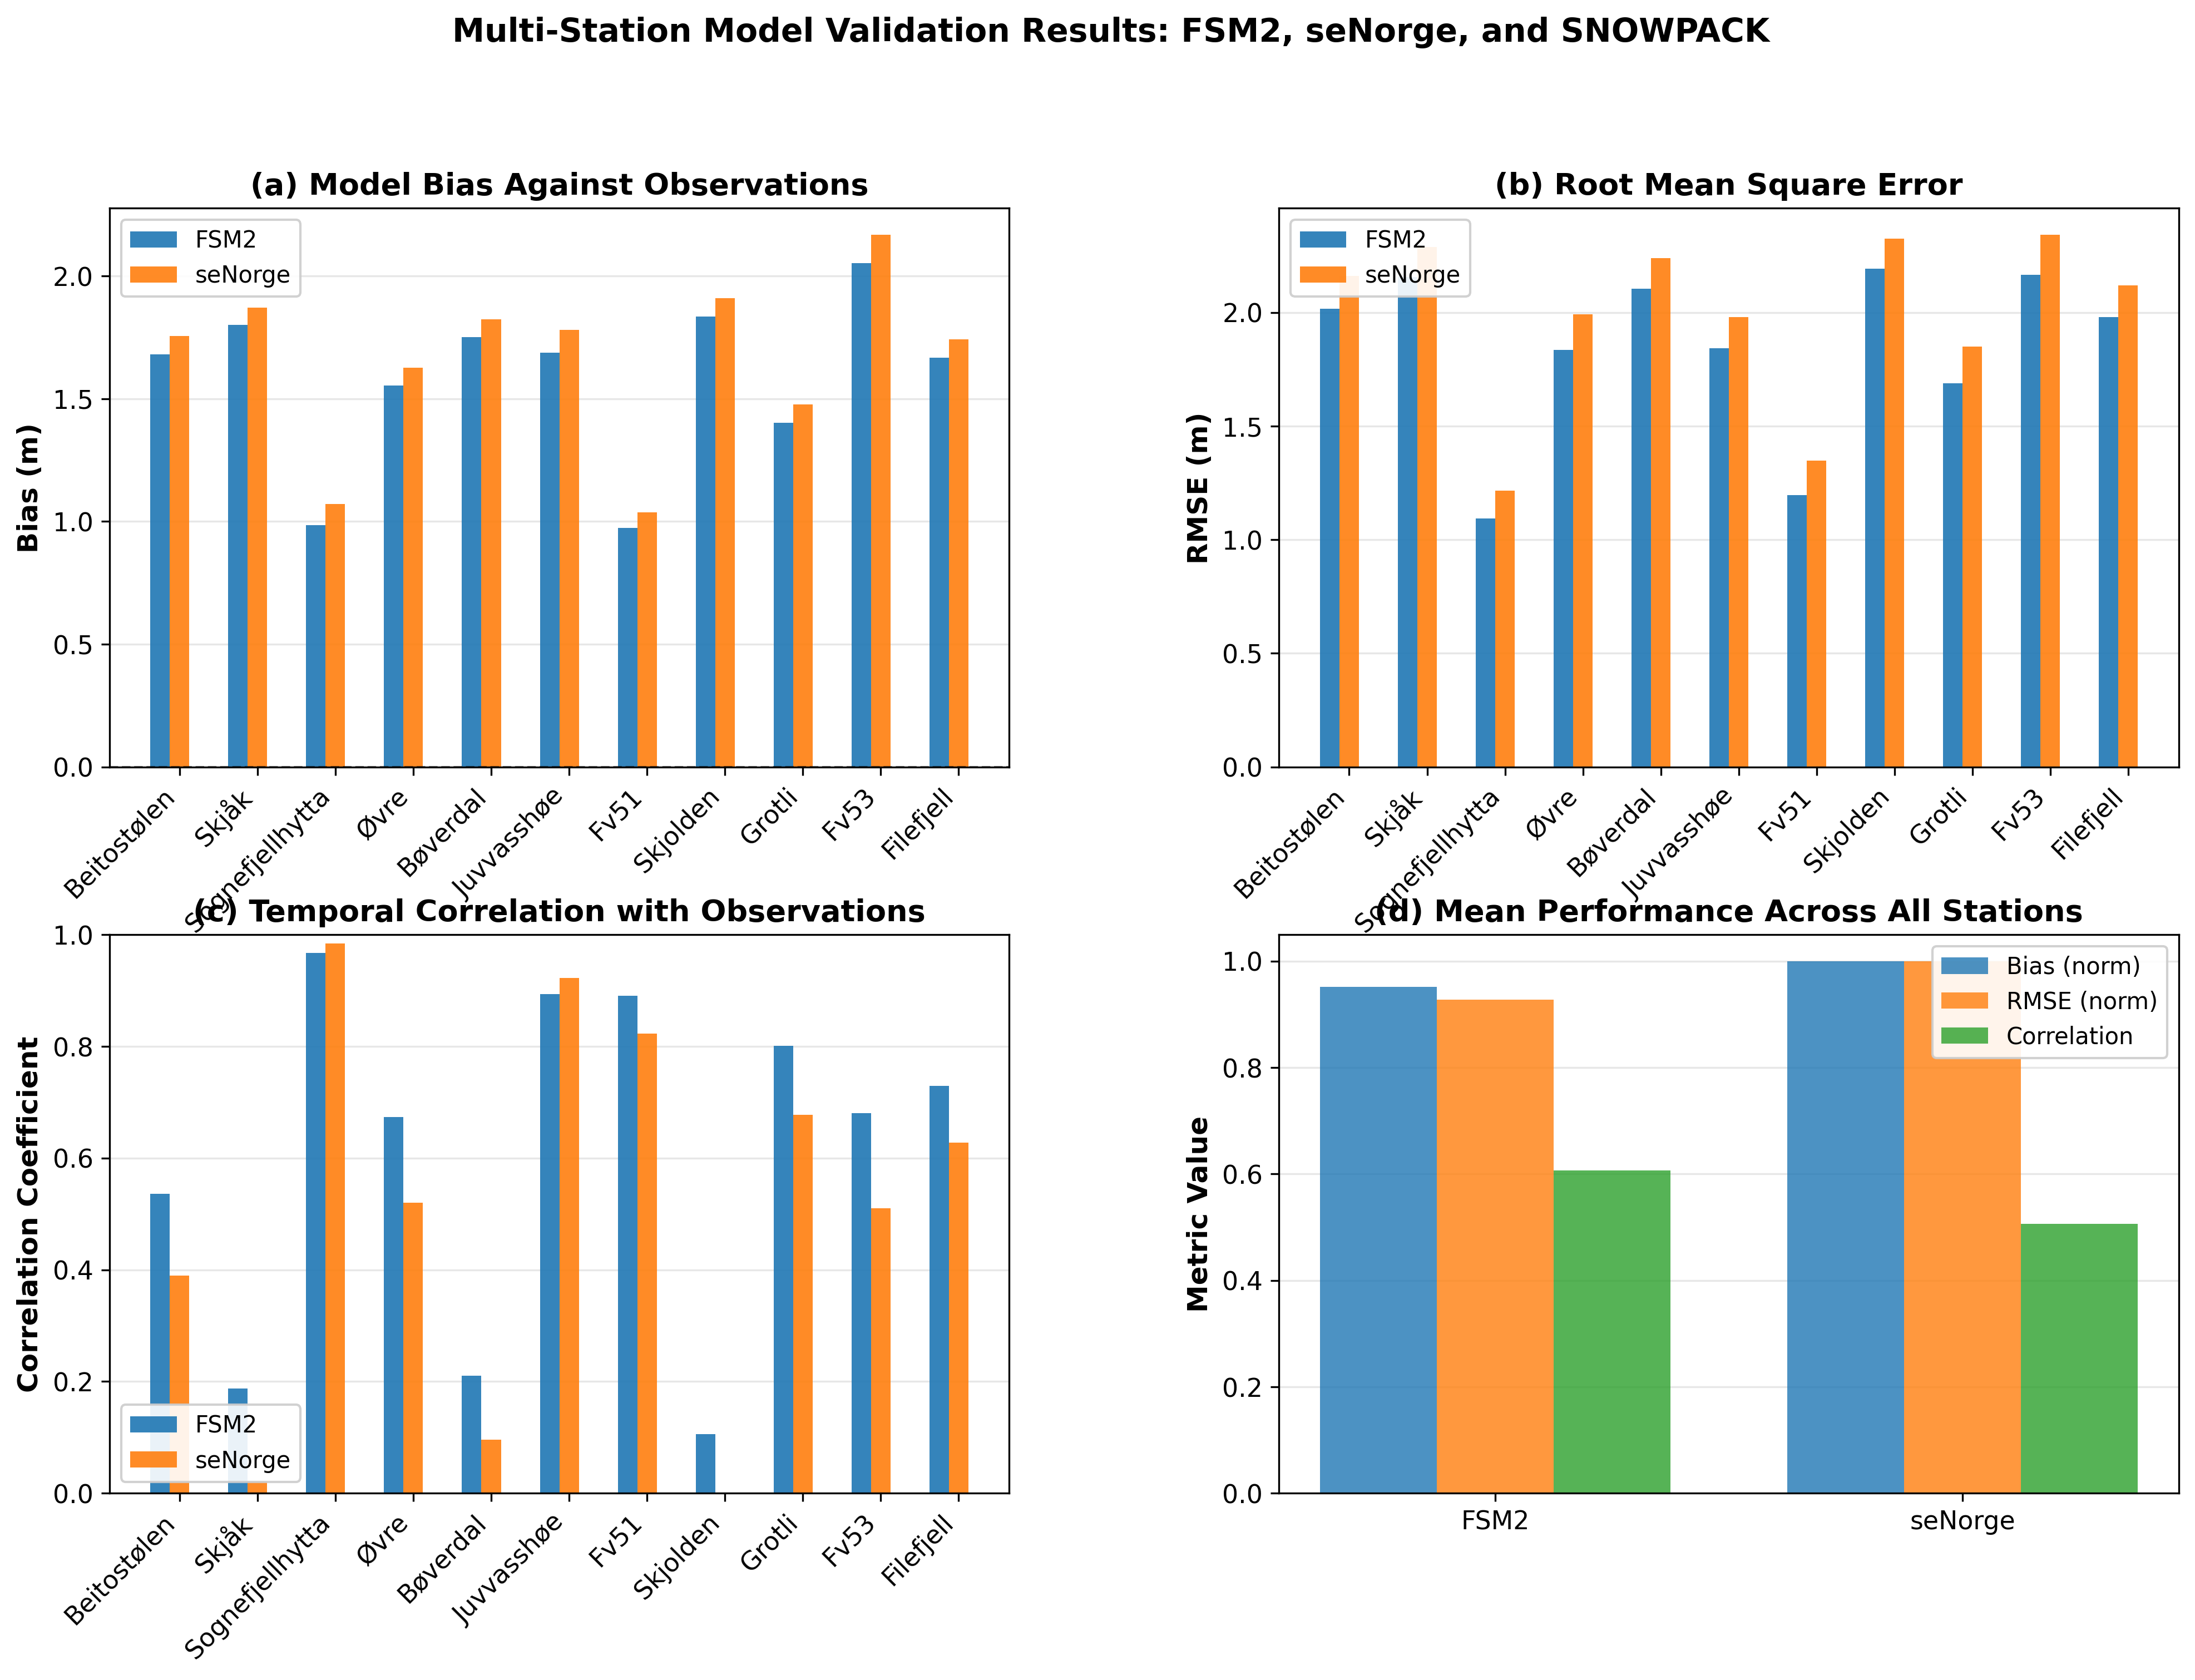

In [13]:
# Create comprehensive 4-panel figure
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.3)

x_pos = np.arange(len(validation_results))
width = 0.25

# Check if SNOWPACK columns exist
has_snowpack = 'SNOWPACK_Bias' in validation_results.columns

# Panel 1: Bias
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(x_pos - width, validation_results['FSM2_Bias'], width, label='FSM2', alpha=0.9)
ax1.bar(x_pos, validation_results['seNorge_Bias'], width, label='seNorge', alpha=0.9)
if has_snowpack:
    ax1.bar(x_pos + width, validation_results['SNOWPACK_Bias'], width, label='SNOWPACK', alpha=0.9)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.set_ylabel('Bias (m)', fontweight='bold')
ax1.set_title('(a) Model Bias Against Observations', fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([s.split()[0] for s in validation_results['Station']], rotation=45, ha='right')
ax1.legend(loc='upper left', framealpha=0.9)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_axisbelow(True)

# Panel 2: RMSE
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(x_pos - width, validation_results['FSM2_RMSE'], width, label='FSM2', alpha=0.9)
ax2.bar(x_pos, validation_results['seNorge_RMSE'], width, label='seNorge', alpha=0.9)
if has_snowpack:
    ax2.bar(x_pos + width, validation_results['SNOWPACK_RMSE'], width, label='SNOWPACK', alpha=0.9)
ax2.set_ylabel('RMSE (m)', fontweight='bold')
ax2.set_title('(b) Root Mean Square Error', fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([s.split()[0] for s in validation_results['Station']], rotation=45, ha='right')
ax2.legend(loc='upper left', framealpha=0.9)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_axisbelow(True)

# Panel 3: Correlation
ax3 = fig.add_subplot(gs[1, 0])
ax3.bar(x_pos - width, validation_results['FSM2_Corr'], width, label='FSM2', alpha=0.9)
ax3.bar(x_pos, validation_results['seNorge_Corr'], width, label='seNorge', alpha=0.9)
if has_snowpack:
    ax3.bar(x_pos + width, validation_results['SNOWPACK_Corr'], width, label='SNOWPACK', alpha=0.9)
ax3.set_ylabel('Correlation Coefficient', fontweight='bold')
ax3.set_title('(c) Temporal Correlation with Observations', fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels([s.split()[0] for s in validation_results['Station']], rotation=45, ha='right')
ax3.set_ylim([0, 1])
ax3.legend(loc='lower left', framealpha=0.9)
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_axisbelow(True)

# Panel 4: Mean performance across stations
ax4 = fig.add_subplot(gs[1, 1])

if has_snowpack:
    models = ['FSM2', 'seNorge', 'SNOWPACK']
    mean_bias = [validation_results['FSM2_Bias'].mean(), validation_results['seNorge_Bias'].mean(), validation_results['SNOWPACK_Bias'].mean()]
    mean_rmse = [validation_results['FSM2_RMSE'].mean(), validation_results['seNorge_RMSE'].mean(), validation_results['SNOWPACK_RMSE'].mean()]
    mean_corr = [validation_results['FSM2_Corr'].mean(), validation_results['seNorge_Corr'].mean(), validation_results['SNOWPACK_Corr'].mean()]
else:
    models = ['FSM2', 'seNorge']
    mean_bias = [validation_results['FSM2_Bias'].mean(), validation_results['seNorge_Bias'].mean()]
    mean_rmse = [validation_results['FSM2_RMSE'].mean(), validation_results['seNorge_RMSE'].mean()]
    mean_corr = [validation_results['FSM2_Corr'].mean(), validation_results['seNorge_Corr'].mean()]

x_models = np.arange(len(models))
width_models = 0.25

# Normalize metrics for visualization (different scales)
mean_bias_norm = np.array(mean_bias) / max([abs(x) for x in mean_bias]) if max([abs(x) for x in mean_bias]) > 0 else mean_bias
mean_rmse_norm = np.array(mean_rmse) / max(mean_rmse)
mean_corr_arr = np.array(mean_corr)

ax4.bar(x_models - width_models, mean_bias_norm, width_models, label='Bias (norm)', alpha=0.8)
ax4.bar(x_models, mean_rmse_norm, width_models, label='RMSE (norm)', alpha=0.8)
ax4.bar(x_models + width_models, mean_corr_arr, width_models, label='Correlation', alpha=0.8)
ax4.set_ylabel('Metric Value', fontweight='bold')
ax4.set_title('(d) Mean Performance Across All Stations', fontweight='bold')
ax4.set_xticks(x_models)
ax4.set_xticklabels(models)
ax4.legend(framealpha=0.9)
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_axisbelow(True)

if not has_snowpack:
    print("⚠️  Note: SNOWPACK validation results not available in CSV")

plt.suptitle('Multi-Station Model Validation Results: FSM2, seNorge, and SNOWPACK', 
             fontsize=14, fontweight='bold', y=0.995)
plt.savefig('../data/processed/Figure_01_Model_Performance_Comparison.png', dpi=300, bbox_inches='tight')
print("✓ Figure 1 saved: Figure_01_Model_Performance_Comparison.png")
plt.show()

## Figure 2: Sample Time Series at Selected Stations

In [14]:
# Select 2-3 representative stations
# Pick best, worst, and middle performing stations
if 'SNOWPACK_RMSE' in validation_results.columns:
    validation_results['Mean_RMSE'] = (validation_results['FSM2_RMSE'] + 
                                         validation_results['seNorge_RMSE'] + 
                                         validation_results['SNOWPACK_RMSE']) / 3
else:
    validation_results['Mean_RMSE'] = (validation_results['FSM2_RMSE'] + 
                                         validation_results['seNorge_RMSE']) / 2

best_station_idx = validation_results['Mean_RMSE'].idxmin()
worst_station_idx = validation_results['Mean_RMSE'].idxmax()
mid_station_idx = validation_results['Mean_RMSE'].abs().sub(validation_results['Mean_RMSE'].median()).abs().idxmin()

selected_stations = [best_station_idx, mid_station_idx, worst_station_idx]
selected_names = [validation_results.loc[idx, 'Station'] for idx in selected_stations]

print(f"Selected stations for time series:")
print(f"  Best: {selected_names[0]} (Mean RMSE: {validation_results.loc[best_station_idx, 'Mean_RMSE']:.4f})")
print(f"  Middle: {selected_names[1]} (Mean RMSE: {validation_results.loc[mid_station_idx, 'Mean_RMSE']:.4f})")
print(f"  Worst: {selected_names[2]} (Mean RMSE: {validation_results.loc[worst_station_idx, 'Mean_RMSE']:.4f})")

Selected stations for time series:
  Best: Sognefjellhytta (Mean RMSE: 1.1547)
  Middle: Filefjell - Kyrkjestølane (Mean RMSE: 2.0494)
  Worst: Skjolden (Mean RMSE: 2.2590)


## Figure 3: Detailed Comparison of Model Errors

✓ Figure 2 saved: Figure_02_Error_Comparison_RMSE.png


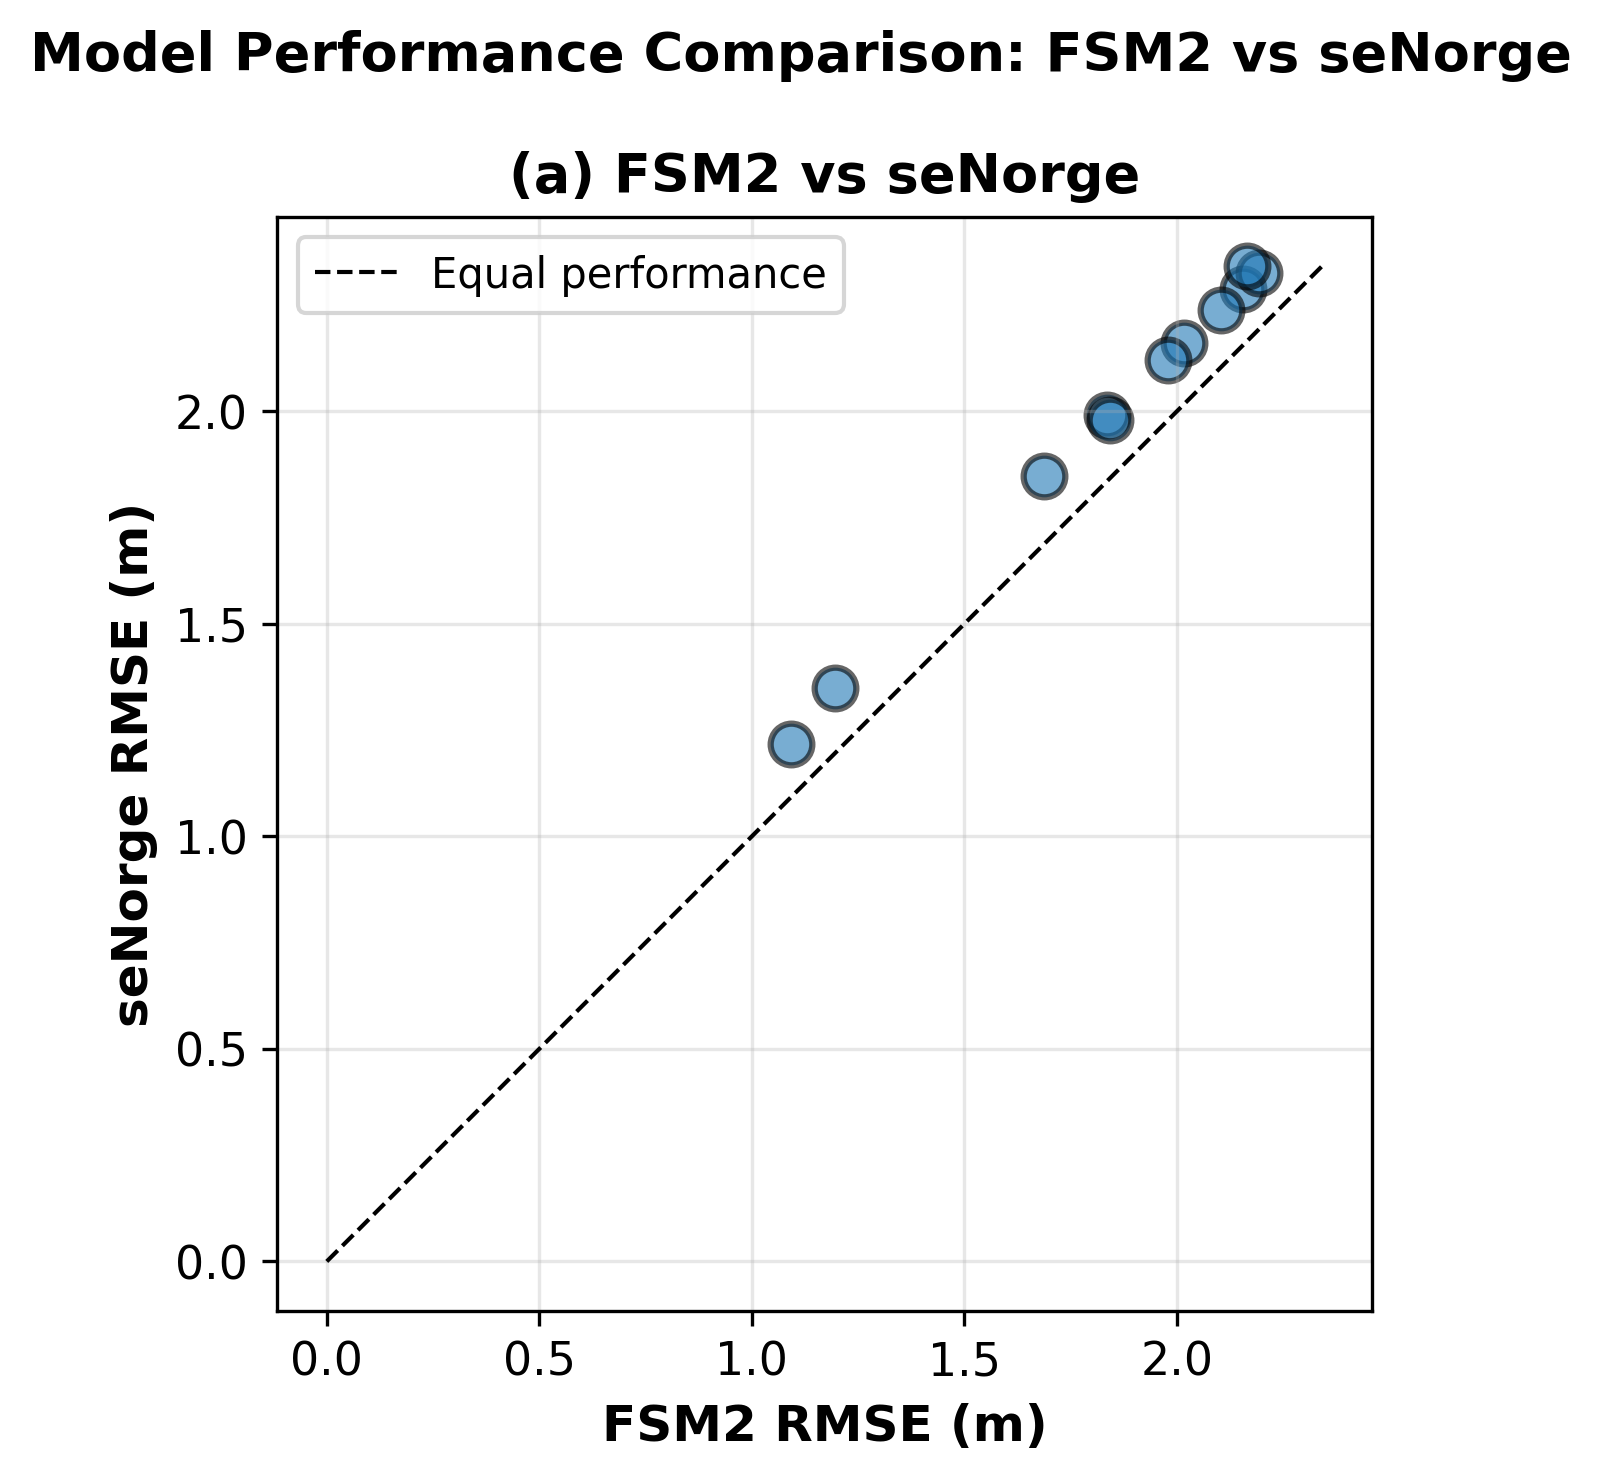

In [15]:
# Create scatter plots: Model vs Observations performance
if 'SNOWPACK_RMSE' in validation_results.columns:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
else:
    fig, axes = plt.subplots(1, 1, figsize=(6, 5))
    axes = [axes]

# FSM2 vs seNorge
ax = axes[0]
ax.scatter(validation_results['FSM2_RMSE'], validation_results['seNorge_RMSE'], 
          s=100, alpha=0.6, edgecolors='black', linewidth=1.5)
max_rmse = max(validation_results['FSM2_RMSE'].max(), validation_results['seNorge_RMSE'].max())
ax.plot([0, max_rmse], [0, max_rmse], 'k--', linewidth=1, label='Equal performance')
ax.set_xlabel('FSM2 RMSE (m)', fontweight='bold')
ax.set_ylabel('seNorge RMSE (m)', fontweight='bold')
ax.set_title('(a) FSM2 vs seNorge', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_aspect('equal')

# FSM2 vs SNOWPACK
if 'SNOWPACK_RMSE' in validation_results.columns and len(axes) > 1:
    ax = axes[1]
    ax.scatter(validation_results['FSM2_RMSE'], validation_results['SNOWPACK_RMSE'], 
              s=100, alpha=0.6, edgecolors='black', linewidth=1.5, color='orange')
    max_rmse = max(validation_results['FSM2_RMSE'].max(), validation_results['SNOWPACK_RMSE'].max())
    ax.plot([0, max_rmse], [0, max_rmse], 'k--', linewidth=1, label='Equal performance')
    ax.set_xlabel('FSM2 RMSE (m)', fontweight='bold')
    ax.set_ylabel('SNOWPACK RMSE (m)', fontweight='bold')
    ax.set_title('(b) FSM2 vs SNOWPACK', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_aspect('equal')

    # seNorge vs SNOWPACK
    ax = axes[2]
    ax.scatter(validation_results['seNorge_RMSE'], validation_results['SNOWPACK_RMSE'], 
              s=100, alpha=0.6, edgecolors='black', linewidth=1.5, color='green')
    max_rmse = max(validation_results['seNorge_RMSE'].max(), validation_results['SNOWPACK_RMSE'].max())
    ax.plot([0, max_rmse], [0, max_rmse], 'k--', linewidth=1, label='Equal performance')
    ax.set_xlabel('seNorge RMSE (m)', fontweight='bold')
    ax.set_ylabel('SNOWPACK RMSE (m)', fontweight='bold')
    ax.set_title('(c) seNorge vs SNOWPACK', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_aspect('equal')
    plt.suptitle('Pairwise Model Performance Comparison (RMSE)', fontsize=13, fontweight='bold')
else:
    plt.suptitle('Model Performance Comparison: FSM2 vs seNorge', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/Figure_02_Error_Comparison_RMSE.png', dpi=300, bbox_inches='tight')
print("✓ Figure 2 saved: Figure_02_Error_Comparison_RMSE.png")
plt.show()

## Figure 4: Model Skill Assessment

/var/folders/4n/m1gxpf611c158s8wx2jzfqgw0000gn/T/ipykernel_10892/709066988.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_rmse, labels=labels_rmse, patch_artist=True)
/var/folders/4n/m1gxpf611c158s8wx2jzfqgw0000gn/T/ipykernel_10892/709066988.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_corr, labels=labels_corr, patch_artist=True)
/var/folders/4n/m1gxpf611c158s8wx2jzfqgw0000gn/T/ipykernel_10892/709066988.py:84: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_bias, labels=labels_bias, patch_artist=True)


✓ Figure 3 saved: Figure_03_Model_Skill_Summary.png


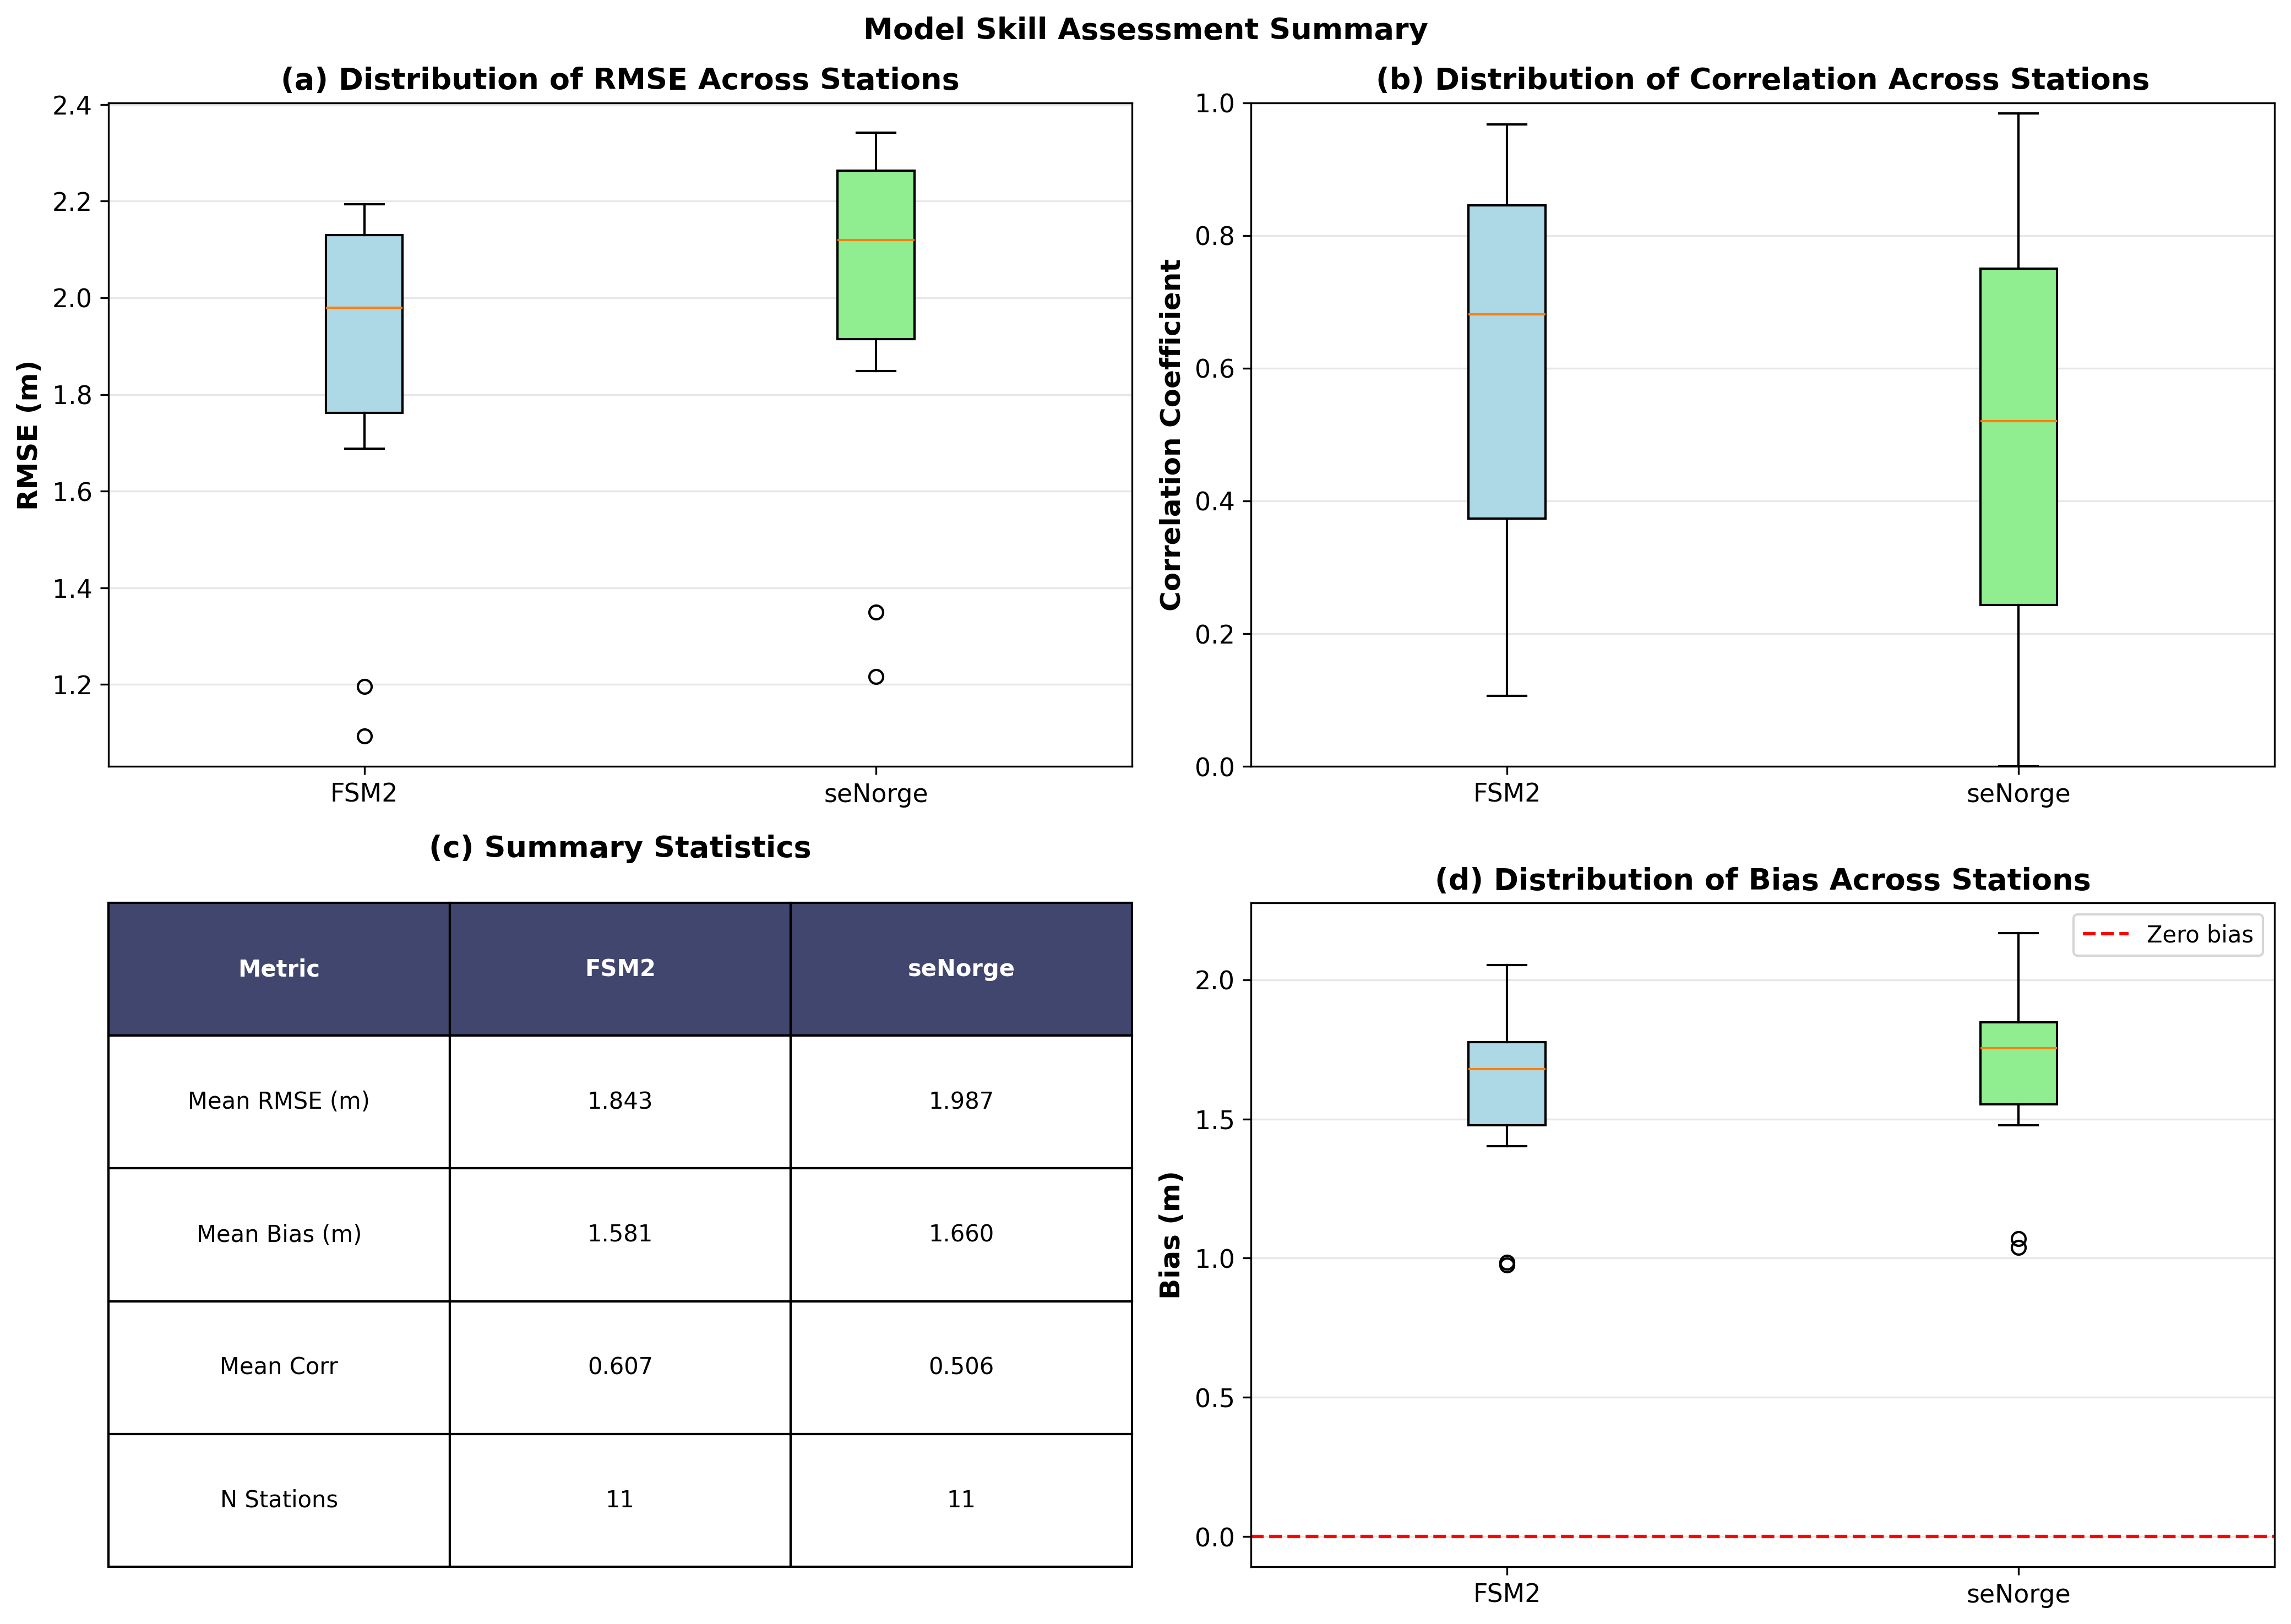

In [16]:
# Create summary statistics visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

has_sp = 'SNOWPACK_RMSE' in validation_results.columns

# 1. Distribution of RMSE values
ax = axes[0, 0]
if has_sp:
    data_rmse = [validation_results['FSM2_RMSE'], validation_results['seNorge_RMSE'], validation_results['SNOWPACK_RMSE']]
    labels_rmse = ['FSM2', 'seNorge', 'SNOWPACK']
else:
    data_rmse = [validation_results['FSM2_RMSE'], validation_results['seNorge_RMSE']]
    labels_rmse = ['FSM2', 'seNorge']
bp = ax.boxplot(data_rmse, labels=labels_rmse, patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightblue', 'lightgreen', 'lightyellow'][:len(data_rmse)]):
    patch.set_facecolor(color)
ax.set_ylabel('RMSE (m)', fontweight='bold')
ax.set_title('(a) Distribution of RMSE Across Stations', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 2. Distribution of Correlation
ax = axes[0, 1]
if has_sp:
    data_corr = [validation_results['FSM2_Corr'], validation_results['seNorge_Corr'], validation_results['SNOWPACK_Corr']]
    labels_corr = ['FSM2', 'seNorge', 'SNOWPACK']
else:
    data_corr = [validation_results['FSM2_Corr'], validation_results['seNorge_Corr']]
    labels_corr = ['FSM2', 'seNorge']
bp = ax.boxplot(data_corr, labels=labels_corr, patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightblue', 'lightgreen', 'lightyellow'][:len(data_corr)]):
    patch.set_facecolor(color)
ax.set_ylabel('Correlation Coefficient', fontweight='bold')
ax.set_title('(b) Distribution of Correlation Across Stations', fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')

# 3. Mean metrics table as text
ax = axes[1, 0]
ax.axis('off')
if has_sp:
    metrics_data = [
        ['Metric', 'FSM2', 'seNorge', 'SNOWPACK'],
        ['Mean RMSE (m)', f"{validation_results['FSM2_RMSE'].mean():.3f}", 
         f"{validation_results['seNorge_RMSE'].mean():.3f}",
         f"{validation_results['SNOWPACK_RMSE'].mean():.3f}"],
        ['Mean Bias (m)', f"{validation_results['FSM2_Bias'].mean():.3f}", 
         f"{validation_results['seNorge_Bias'].mean():.3f}",
         f"{validation_results['SNOWPACK_Bias'].mean():.3f}"],
        ['Mean Corr', f"{validation_results['FSM2_Corr'].mean():.3f}", 
         f"{validation_results['seNorge_Corr'].mean():.3f}",
         f"{validation_results['SNOWPACK_Corr'].mean():.3f}"],
        ['N Stations', str(len(validation_results)), str(len(validation_results)), str(len(validation_results))]
    ]
else:
    metrics_data = [
        ['Metric', 'FSM2', 'seNorge'],
        ['Mean RMSE (m)', f"{validation_results['FSM2_RMSE'].mean():.3f}", 
         f"{validation_results['seNorge_RMSE'].mean():.3f}"],
        ['Mean Bias (m)', f"{validation_results['FSM2_Bias'].mean():.3f}", 
         f"{validation_results['seNorge_Bias'].mean():.3f}"],
        ['Mean Corr', f"{validation_results['FSM2_Corr'].mean():.3f}", 
         f"{validation_results['seNorge_Corr'].mean():.3f}"],
        ['N Stations', str(len(validation_results)), str(len(validation_results))]
    ]
table = ax.table(cellText=metrics_data, cellLoc='center', loc='center', 
                bbox=[0, 0, 1, 1], colWidths=[0.25] * len(metrics_data[0]))
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
# Style header row
for i in range(len(metrics_data[0])):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')
ax.set_title('(c) Summary Statistics', fontweight='bold', pad=20)

# 4. Bias distribution
ax = axes[1, 1]
if has_sp:
    data_bias = [validation_results['FSM2_Bias'], validation_results['seNorge_Bias'], validation_results['SNOWPACK_Bias']]
    labels_bias = ['FSM2', 'seNorge', 'SNOWPACK']
else:
    data_bias = [validation_results['FSM2_Bias'], validation_results['seNorge_Bias']]
    labels_bias = ['FSM2', 'seNorge']
bp = ax.boxplot(data_bias, labels=labels_bias, patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightblue', 'lightgreen', 'lightyellow'][:len(data_bias)]):
    patch.set_facecolor(color)
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Zero bias')
ax.set_ylabel('Bias (m)', fontweight='bold')
ax.set_title('(d) Distribution of Bias Across Stations', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.legend()

plt.suptitle('Model Skill Assessment Summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/Figure_03_Model_Skill_Summary.png', dpi=300, bbox_inches='tight')
print("✓ Figure 3 saved: Figure_03_Model_Skill_Summary.png")
plt.show()

## Figure 5: SNOWPACK Temperature Analysis

✓ Figure 4 saved: Figure_04_SNOWPACK_Temperature.png


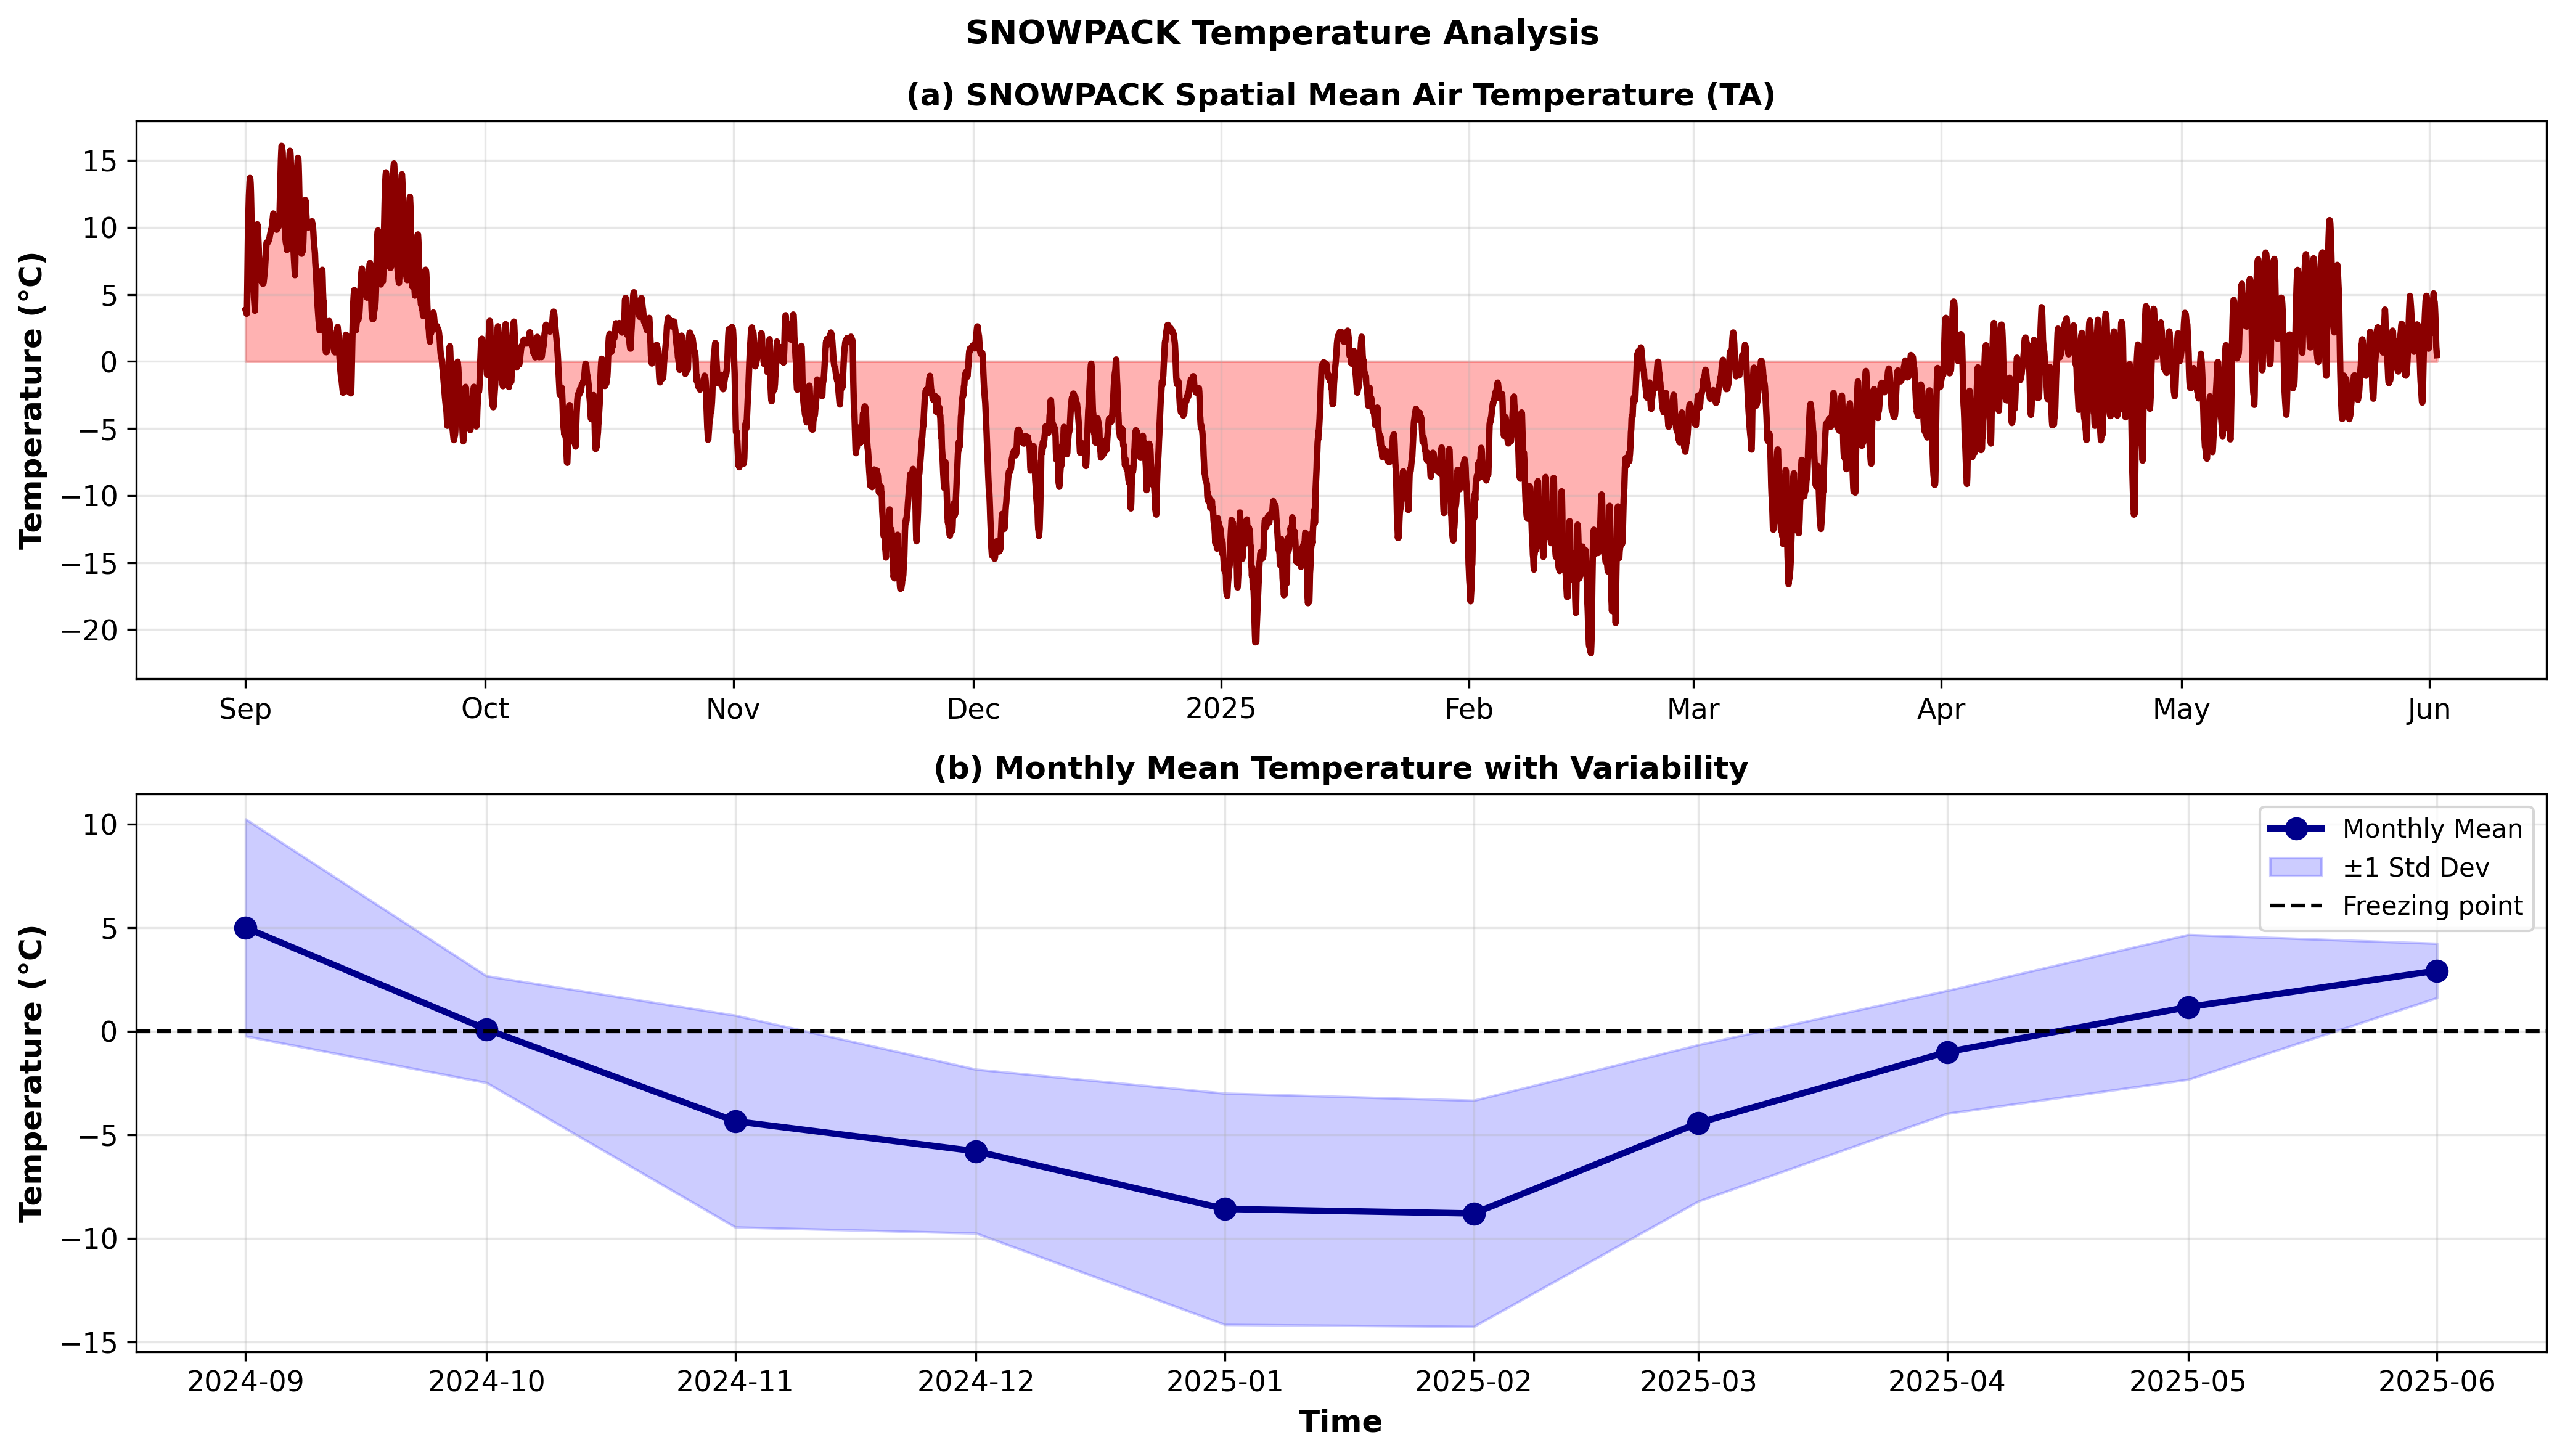

In [17]:
# Extract and visualize SNOWPACK temperature
if 'TA' in snowpack_ds.data_vars:
    snowpack_temp = snowpack_ds['TA']
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    # Spatial mean temperature time series
    spatial_mean_temp = snowpack_temp.mean(dim=[d for d in snowpack_temp.dims if d != 'time'])
    
    # Panel 1: Time series
    ax = axes[0]
    spatial_mean_temp.plot(ax=ax, linewidth=2.5, color='darkred')
    ax.fill_between(spatial_mean_temp.time.values, spatial_mean_temp.values, alpha=0.3, color='red')
    ax.set_ylabel('Temperature (°C)', fontweight='bold', fontsize=12)
    ax.set_title('(a) SNOWPACK Spatial Mean Air Temperature (TA)', fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('')
    
    # Panel 2: Monthly statistics
    ax = axes[1]
    monthly_stats = spatial_mean_temp.resample(time='1MS').mean()
    monthly_std = spatial_mean_temp.resample(time='1MS').std()
    
    ax.plot(monthly_stats.time, monthly_stats.values, marker='o', linewidth=2.5, 
           markersize=8, color='darkblue', label='Monthly Mean')
    ax.fill_between(monthly_stats.time.values, 
                    (monthly_stats.values - monthly_std.values), 
                    (monthly_stats.values + monthly_std.values),
                    alpha=0.2, color='blue', label='±1 Std Dev')
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5, label='Freezing point')
    ax.set_ylabel('Temperature (°C)', fontweight='bold', fontsize=12)
    ax.set_xlabel('Time', fontweight='bold', fontsize=12)
    ax.set_title('(b) Monthly Mean Temperature with Variability', fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')
    
    plt.suptitle('SNOWPACK Temperature Analysis', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../data/processed/Figure_04_SNOWPACK_Temperature.png', dpi=300, bbox_inches='tight')
    print("✓ Figure 4 saved: Figure_04_SNOWPACK_Temperature.png")
    plt.show()
else:
    print("Temperature data (TA) not found in SNOWPACK dataset")

## Summary: All Figures Generated

In [18]:
print("\n" + "="*80)
print("FIGURES GENERATED FOR MASTER THESIS")
print("="*80)

figures = [
    ("Figure_01_Model_Performance_Comparison.png", "4-panel comparison of Bias, RMSE, Correlation, and mean metrics"),
    ("Figure_02_Error_Comparison_RMSE.png", "Pairwise model RMSE comparison scatter plots"),
    ("Figure_03_Model_Skill_Summary.png", "Distribution plots and summary statistics table"),
    ("Figure_04_SNOWPACK_Temperature.png", "Temperature time series and monthly statistics")
]

for i, (filename, description) in enumerate(figures, 1):
    print(f"\n{i}. {filename}")
    print(f"   {description}")
    print(f"   Location: ../data/processed/{filename}")

print(f"\n" + "="*80)
print("All figures are saved at 300 dpi for publication quality")
print("Recommended use: Insert directly into thesis document")
print("="*80)


FIGURES GENERATED FOR MASTER THESIS

1. Figure_01_Model_Performance_Comparison.png
   4-panel comparison of Bias, RMSE, Correlation, and mean metrics
   Location: ../data/processed/Figure_01_Model_Performance_Comparison.png

2. Figure_02_Error_Comparison_RMSE.png
   Pairwise model RMSE comparison scatter plots
   Location: ../data/processed/Figure_02_Error_Comparison_RMSE.png

3. Figure_03_Model_Skill_Summary.png
   Distribution plots and summary statistics table
   Location: ../data/processed/Figure_03_Model_Skill_Summary.png

4. Figure_04_SNOWPACK_Temperature.png
   Temperature time series and monthly statistics
   Location: ../data/processed/Figure_04_SNOWPACK_Temperature.png

All figures are saved at 300 dpi for publication quality
Recommended use: Insert directly into thesis document
